In [1]:
import os
import sys

import math
import time
import datetime
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import torch
from torch.utils.data import Dataset
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
# from YourDataset import YourDataset  # Import your custom dataset here
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler
from torchinfo import summary
import torchprofile

from utils.architecture import Unet
from utils.diffusion import ElucidatedDiffusion

torch.manual_seed(23)
import pickle

DTYPE = torch.float32

scaler = GradScaler()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 200
plt.rcParams["font.family"] = "serif"

import scipy.stats as stats
from sklearn.decomposition import TruncatedSVD

Using device: cuda


In [2]:
def error_metric(pred,true, Par):
    #re-normalize
    # true = true*Par['out_scale'] + Par['out_shift']
    # true = true*Par['out_scale'] + Par['out_shift']
    return torch.norm(true-pred, p=2)/torch.norm(true, p=2)

class MyDataset(Dataset):
    def __init__(self, x, y, transform=None):
        self.x = x
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_sample = self.x[idx]
        y_sample = self.y[idx]

        if self.transform:
            x_sample, y_sample = self.transform(x_sample, y_sample)

        return x_sample, y_sample
    
def preprocess(x,y, Par):
    x = sliding_window_view(x[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])
    y = sliding_window_view(y[:,Par['lb']-1:,:,:], window_shape=Par['lf'], axis=1 ).transpose(0,1,4,2,3).reshape(-1,Par['lf'],Par['nx'], Par['ny'])

    print('x: ', x.shape)
    print('y: ', y.shape)
    print()
    return x,y


In [3]:
res = 128
begin_time = time.time()

x_train = np.load("../TRAIN_PRED.npy")
y_train = np.load("../TRAIN_TRUE.npy")

x_val = np.load("../VAL_PRED.npy")
y_val = np.load("../VAL_TRUE.npy")

x_test = np.load("../TEST_PRED.npy")
y_test = np.load("../TEST_TRUE.npy")
print(f"Data Loading Time: {time.time() - begin_time:.1f}s")


inp_min = np.min(x_train)
inp_max = np.max(x_train)
out_min = np.min(y_train)
out_max = np.max(y_train)


Par = {"inp_shift" : torch.tensor(inp_min, dtype=DTYPE, device=device),
       "inp_scale" : torch.tensor(inp_max - inp_min, dtype=DTYPE, device=device),
       "out_shift" : torch.tensor(out_min, dtype=DTYPE, device=device),
       "out_scale" : torch.tensor(out_max - out_min, dtype=DTYPE, device=device),
       "nx"        : x_train.shape[2],
       "ny"        : x_train.shape[3],
       "nf"        : 1,
       "lb"        : 1,
       "lf"        : 1,
       "num_epochs": 1000
       }

# Normalizing the data to [0,1]
shift = Par['inp_shift'].detach().cpu().numpy()
scale = Par['inp_scale'].detach().cpu().numpy()
x_train = (x_train - shift)/scale
x_val = (x_val - shift)/scale
x_test = (x_test - shift)/scale

shift = Par['out_shift'].detach().cpu().numpy()
scale = Par['out_scale'].detach().cpu().numpy()
y_train = (y_train - shift)/scale
y_val = (y_val - shift)/scale
y_test = (y_test - shift)/scale

Par["sigma_data"] = np.std(y_train)

# Traj splitting
begin_time = time.time()
print('\nTrain Dataset')
x_train, y_train = preprocess(x_train, y_train, Par)
print('\nValidation Dataset')
x_val, y_val = preprocess(x_val, y_val, Par)
print('\nTest Dataset')
x_test, y_test = preprocess(x_test, y_test, Par)
print(f"Data Preprocess Time: {time.time() - begin_time:.1f}s")

Par.update({"channels"       : x_train.shape[1],
            "self_condition" : True
            })

print("Par")
with open('Par.pkl', 'wb') as f:
    pickle.dump(Par, f)

x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

x_val_tensor   = torch.tensor(x_val,   dtype=torch.float32)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32)

x_test_tensor  = torch.tensor(x_test,  dtype=torch.float32)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32)

train_dataset = MyDataset(x_train_tensor, y_train_tensor)
val_dataset = MyDataset(x_val_tensor, y_val_tensor)
test_dataset = MyDataset(x_test_tensor, y_test_tensor)

# Define data loaders
train_batch_size = 100 #16
val_batch_size   = 100
test_batch_size  = 100
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=val_batch_size)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size)

Data Loading Time: 4.2s

Train Dataset
x:  (16000, 1, 128, 128)
y:  (16000, 1, 128, 128)


Validation Dataset
x:  (2000, 1, 128, 128)
y:  (2000, 1, 128, 128)


Test Dataset
x:  (2000, 1, 128, 128)
y:  (2000, 1, 128, 128)

Data Preprocess Time: 0.0s
Par


In [4]:
# Define Network Architecture
net = Unet(
    dim = 16,
    dim_mults = (1, 2, 4, 8),
    channels = Par["channels"],
    self_condition = Par["self_condition"],
    flash_attn = True
).to(device).to(torch.float32)
summary(net, input_size=((1,)+x_train.shape[1:], (1,)) )

model = ElucidatedDiffusion(net,
                                channels = Par["channels"],
                                image_size_h=Par["nx"],
                                image_size_w=Par["ny"],
                                sigma_data=Par["sigma_data"])

path_model = 'models/best_model.pt'
# path_model = 'models/model_2000.pt'
model.load_state_dict(torch.load(path_model))

Non-A100 GPU detected, using math or mem efficient attention if input tensor is on cuda


<All keys matched successfully>

In [5]:
l_fidel_ls = []
y_pred_ls = []
y_true_ls = []

model.eval()
test_loss = 0.0
with torch.no_grad():
    for l_fidel, h_fidel in test_loader:
        with autocast():
            pred = model.sample(l_fidel.to(device), num_sample_steps=32)
            loss   = error_metric(pred, h_fidel.to(device), Par)
        test_loss += loss.item()
        l_fidel_ls.append(l_fidel)
        y_true_ls.append(h_fidel)
        y_pred_ls.append(pred)

test_loss /= len(test_loader)
print(f'Test Loss: {test_loss:.4e}')

sampling time step: 100%|██████████| 32/32 [00:03<00:00, 10.44it/s]


Test Loss: 9.4196e-02


In [6]:
x_true = np.load("../../fno12_lb10s_lf10s/TEST_X.npy") # Loading initial condition
y_true = torch.cat(y_true_ls, dim=0).detach().cpu().numpy().reshape(-1, 20, Par["nx"], Par["ny"])
y_pred = torch.cat(y_pred_ls, dim=0).detach().cpu().numpy().reshape(-1, 20, Par["nx"], Par["ny"])
y_no   = torch.cat(l_fidel_ls, dim=0).detach().cpu().numpy().reshape(-1,20, Par["nx"], Par["ny"])

# Renormalize from [0,1] to actual distribution
y_true = y_true * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_pred = y_pred * Par['out_scale'].detach().cpu().numpy() + Par['out_shift'].detach().cpu().numpy()
y_no   = y_no   * Par['inp_scale'].detach().cpu().numpy() + Par['inp_shift'].detach().cpu().numpy()

print(f"y_true: {y_true.shape}")
print(f"y_pred: {y_pred.shape}")
print(f"y_no  : {y_no.shape}")

y_true: (100, 20, 128, 128)
y_pred: (100, 20, 128, 128)
y_no  : (100, 20, 128, 128)


In [7]:
def compute_power(true, pred, inp):
    BS, nt, nx, ny = true.shape

    true = torch.tensor(true, device=device, dtype=DTYPE)
    pred = torch.tensor(pred, device=device, dtype=DTYPE)
    inp = torch.tensor(inp, device=device, dtype=DTYPE)
    
    # Compute the Fourier transforms and amplitude squared for both true and pred
    fourier_true = torch.fft.fftn(true, dim=(-2, -1))
    fourier_pred = torch.fft.fftn(pred, dim=(-2, -1))
    fourier_inp  = torch.fft.fftn(inp , dim=(-2, -1))

    # Get the squared amplitudes
    amplitudes_true = torch.abs(fourier_true) ** 2
    amplitudes_pred = torch.abs(fourier_pred) ** 2
    amplitudes_inp = torch.abs(fourier_inp) ** 2

    # Create the k-frequency grids
    kfreq_y = torch.fft.fftfreq(ny) * ny
    kfreq_x = torch.fft.fftfreq(nx) * nx
    kfreq2D_x, kfreq2D_y = torch.meshgrid(kfreq_x, kfreq_y, indexing='ij')
    
    # Compute the wavenumber grid
    knrm = torch.sqrt(kfreq2D_x ** 2 + kfreq2D_y ** 2).to(true.device)
    
    # Define the bins for the wavenumber
    kbins = torch.arange(0.5, nx // 2 + 1, 1.0, device=true.device)
    
    # Digitize knrm to bin indices
    knrm_flat = knrm.flatten()
    bin_indices = torch.bucketize(knrm_flat, kbins)

    # Reshape and flatten the amplitudes
    amplitudes_true_flat = amplitudes_true.view(BS, nt, nx * ny)
    amplitudes_pred_flat = amplitudes_pred.view(BS, nt, nx * ny)
    amplitudes_inp_flat  = amplitudes_inp.view(BS, nt, nx * ny)

    # Initialize Abins
    Abins_true = torch.zeros((BS, nt, len(kbins) - 1), device=true.device)
    Abins_pred = torch.zeros((BS, nt, len(kbins) - 1), device=pred.device)
    Abins_inp  = torch.zeros((BS, nt, len(kbins) - 1), device= inp.device)

    # Vectorized binning: sum up the values in each bin
    for bin_idx in range(1, len(kbins)):
        mask = (bin_indices == bin_idx).unsqueeze(0).unsqueeze(0)  # Create a mask for each bin
        Abins_true[:, :, bin_idx - 1] = (amplitudes_true_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_pred[:, :, bin_idx - 1] = (amplitudes_pred_flat * mask).sum(dim=-1) / mask.sum(dim=-1)
        Abins_inp[:,  :, bin_idx - 1] = (amplitudes_inp_flat  * mask).sum(dim=-1) / mask.sum(dim=-1)

    # Scale the binned amplitudes
    scaling_factor = torch.pi * (kbins[1:] ** 2 - kbins[:-1] ** 2)
    Abins_true *= scaling_factor
    Abins_pred *= scaling_factor
    Abins_inp  *= scaling_factor

    Abins_true = torch.log(Abins_true)
    Abins_pred = torch.log(Abins_pred)
    Abins_inp = torch.log(Abins_inp)
    

    return Abins_true.detach().cpu().numpy(), Abins_pred.detach().cpu().numpy(), Abins_inp.detach().cpu().numpy()

def field_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(2,3) )/np.mean(true**2, axis=(2,3)) )
    # return np.mean(  np.sqrt(np.mean( (true-pred)**2, axis=(2,3) ))  )
    # true = true.reshape(-1,)
    # pred = pred.reshape(-1,)
    # # err = np.linalg.norm(true - pred, ord=2)/np.linalg.norm(true, ord=2)
    # err = np.mean( (true-pred)**2 )/np.mean(true**2)
    # return err

 

def spec_get_err(true, pred):
    return np.mean( np.mean( (true-pred)**2, axis=(1,2)  ) /np.mean(true**2, axis=(1,2) ) )
    # return np.mean(  np.sqrt(np.mean( (true-pred)**2, axis=(1,2) ))  )
    # true = true.reshape(-1,)
    # pred = pred.reshape(-1,)
    # # err = np.linalg.norm(true - pred, ord=2)/np.linalg.norm(true, ord=2)
    # err = np.mean( (true-pred)**2 )/np.mean(true**2)
    # return err

spec_true, spec_pred, spec_no = compute_power(y_true, y_pred, y_no)


field_err_pred = field_get_err(y_true, y_pred)
field_err_no = field_get_err(y_true, y_no)

print(f"field error: nodm = {field_err_pred:.4e}, no = {field_err_no:.4e}")

spec_err_pred = spec_get_err(spec_true, spec_pred)
spec_err_no = spec_get_err(spec_true, spec_no)

print(f"spec error : nodm = {spec_err_pred:.4e}, no = {spec_err_no:.4e}")

field error: nodm = 6.0385e-02, no = 5.5177e-02
spec error : nodm = 2.5666e-03, no = 1.8960e-02


In [7]:
np.save("x_true.npy", x_true)
np.save("y_true.npy", y_true)
np.save("y_no.npy", y_no)
np.save("y_pred.npy", y_pred)

In [9]:
t_ls = np.linspace(0,25,51)[4:]
t_ls

array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  6.5,  7. ,
        7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5, 12. , 12.5,
       13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. , 17.5, 18. ,
       18.5, 19. , 19.5, 20. , 20.5, 21. , 21.5, 22. , 22.5, 23. , 23.5,
       24. , 24.5, 25. ])

k_nq: 64.0
(5, 128, 128)
[12. 14. 16. 18. 20.]


/tmp/ipykernel_3209416/2297410832.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1], pad=1.5, w_pad=0., h_pad=0.)


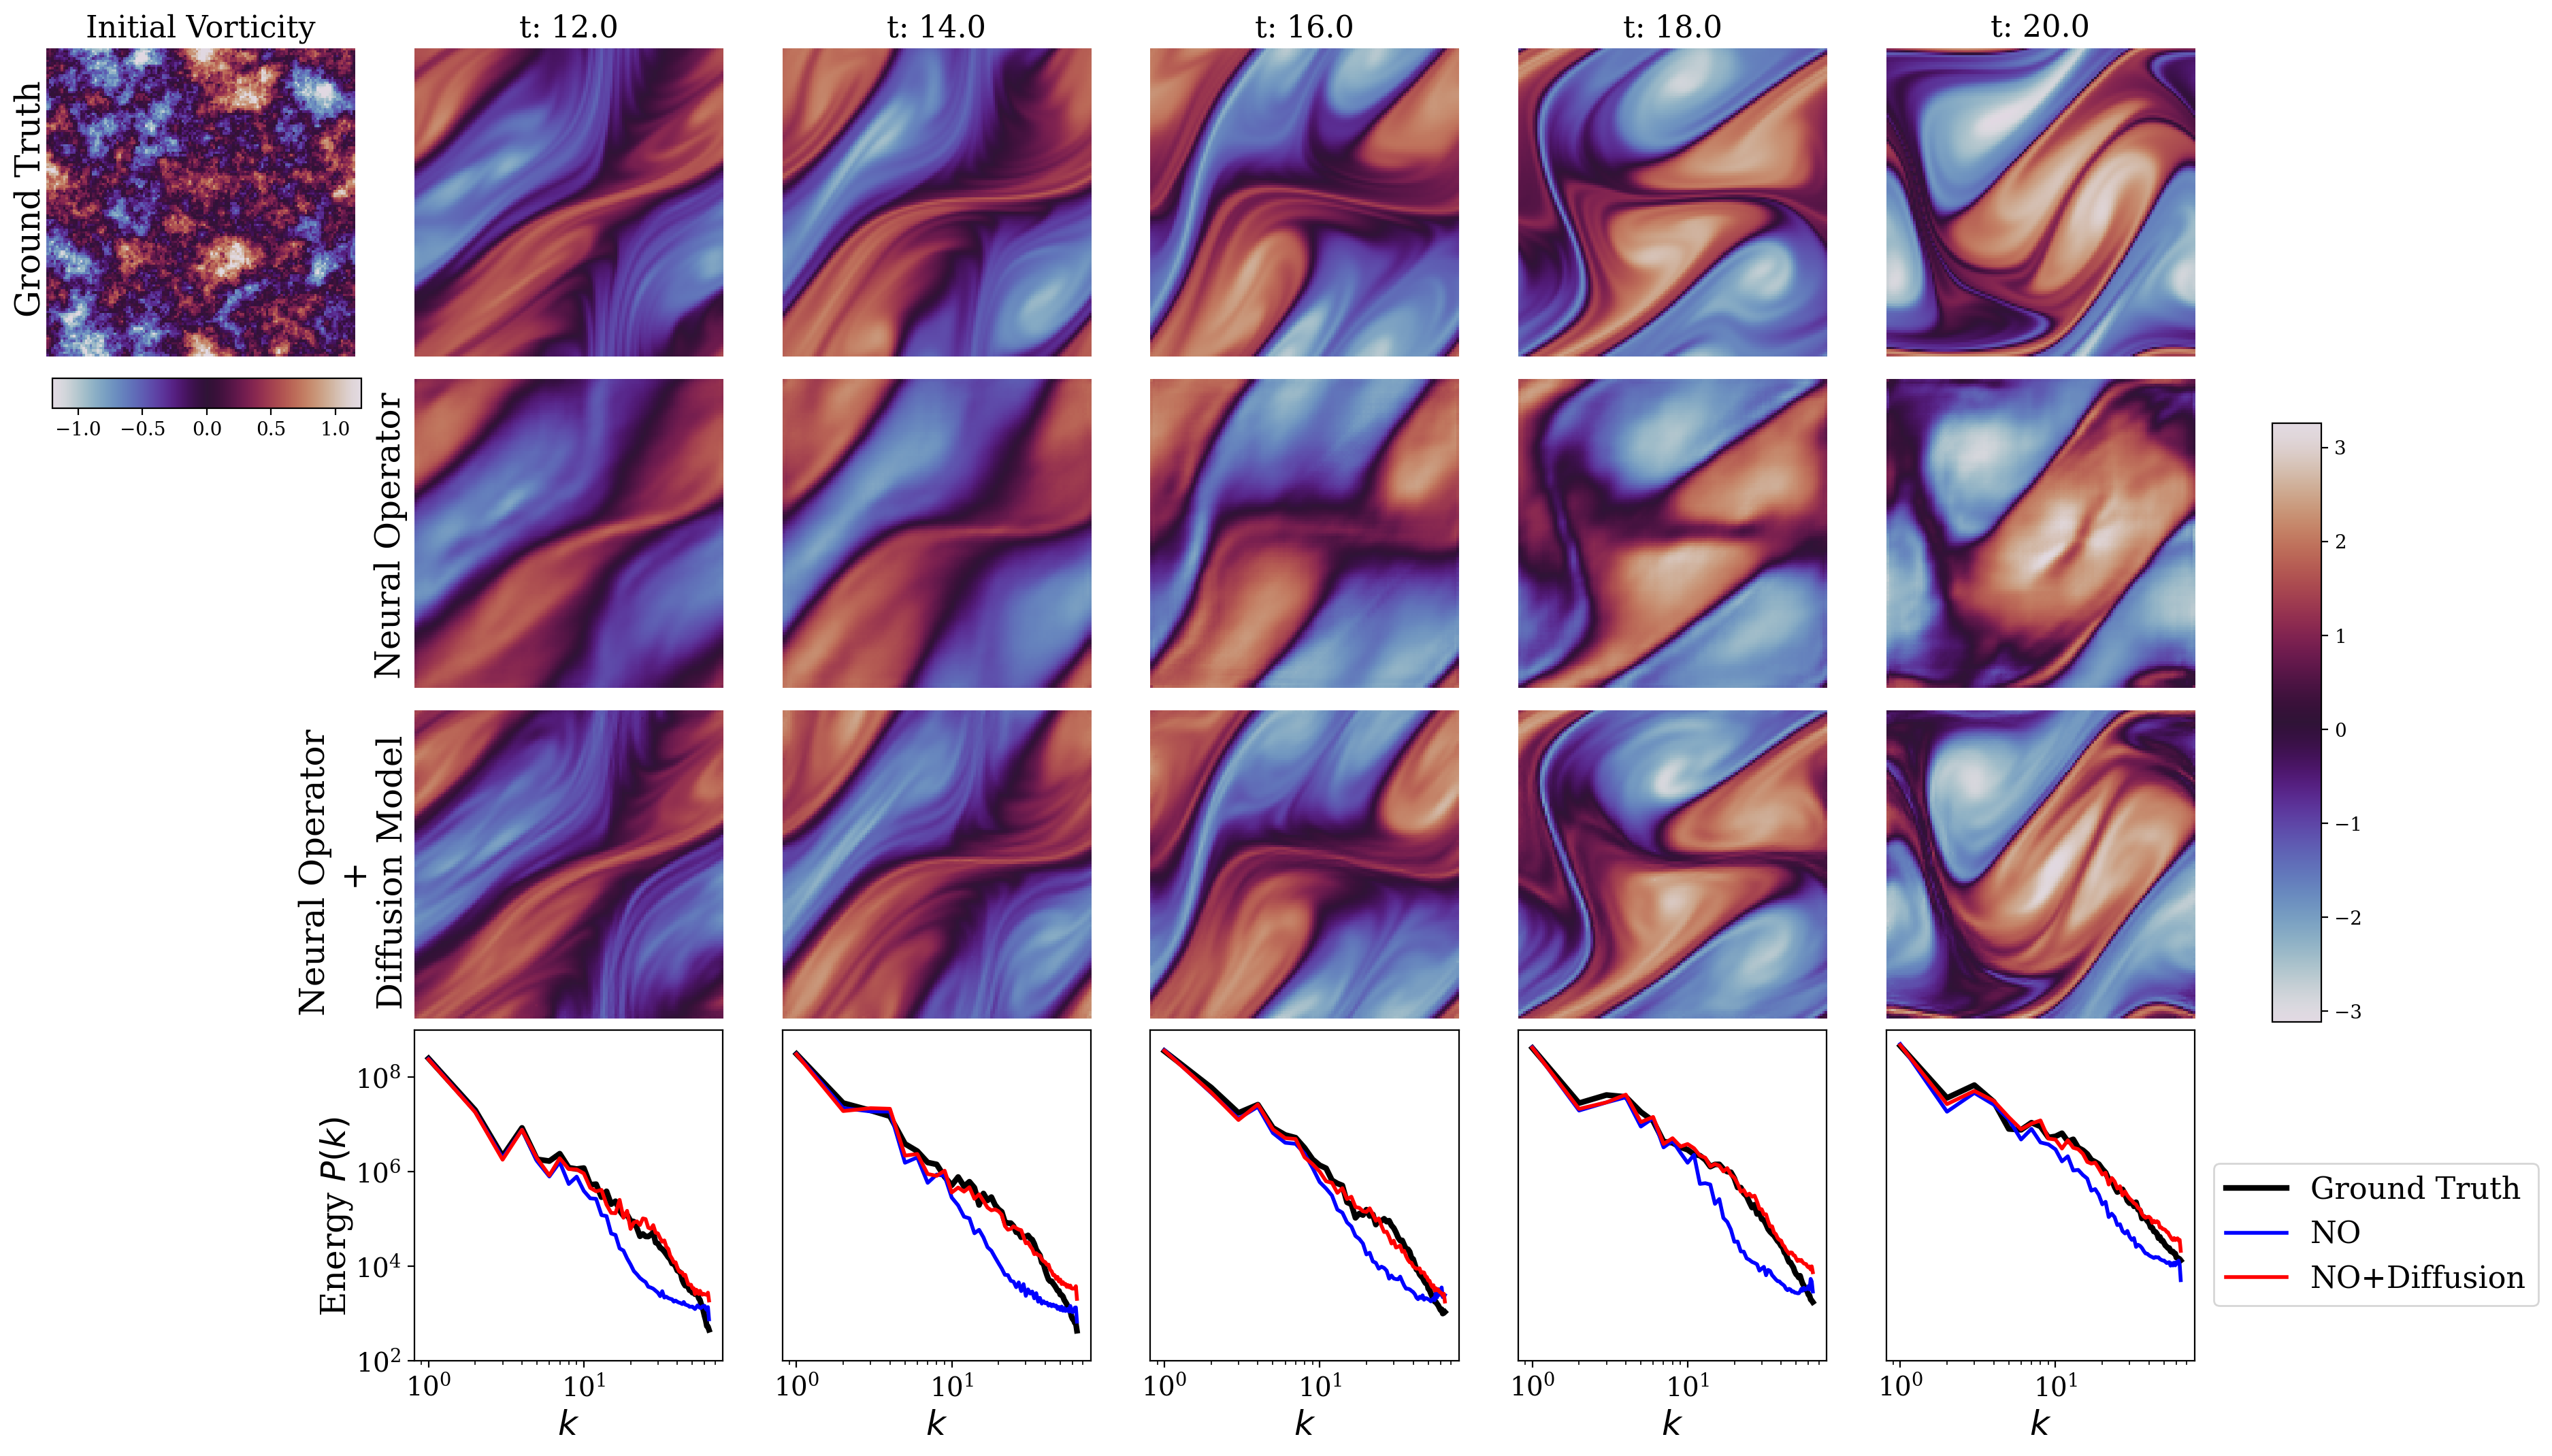

In [10]:
L = 2*np.pi
N = np.min(y_true.shape[2:])
delta_x = L/N
k_nq = np.pi/delta_x
print(f"k_nq: {k_nq}")

for p in [3]:#range(10):
    sample_id = p
    skip_t = 4
    t_ls = np.linspace(10,20,21)[1:]
    init = x_true[sample_id, 0]
    true = y_true[sample_id, 3:][::skip_t]#[1:]
    pred1 = y_no[sample_id, 3:][::skip_t]#[1:]
    pred2 = y_pred[sample_id, 3:][::skip_t]#[1:]
    time_ls = t_ls[3:][::skip_t]#[1:]
    
    print(true.shape)
    print(time_ls)
    
    CMAP = 'twilight'
    
    # Function to calculate MSE
    def mse(a, b):
        return np.mean((a - b) ** 2)
    
    def rel_l2(T, P):
        T = torch.tensor(T, dtype=DTYPE)
        P = torch.tensor(P, dtype=DTYPE)
        return torch.norm(T-P, p=2)/torch.norm(T, p=2).cpu().numpy()
    
    # Create the figure and axis
    fig, axes = plt.subplots(4, 6, figsize=(18, 11))
    cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])  # Colorbar axis
    
    # Find the min and max values for colorbar
    vmin = min(true.min(), pred1.min(), pred2.min())
    vmax = max(true.max(), pred1.max(), pred2.max())

    for ax in axes[1:, 0]:  # This loops over the first column from the second row onwards
        ax.axis('off')  # Turn these axes off as they are not used
    
    # Plot the images
    for i1 in range(6):
        if i1==0:
            # im = axes[0, i1].imshow(init, vmin=init.min(), vmax=init.max(), cmap=CMAP)
            im = axes[0, i1].imshow(init, vmin=-1.2, vmax=1.2, cmap=CMAP)
            axes[0, i1].set_title(f'Initial Vorticity', fontsize=16)
            axes[0, i1].axis('off') 
            cbar_init_ax = fig.add_axes([0.014, 0.71, 0.126, 0.02])  # (left, bottom, width, height)
            fig.colorbar(im, cax=cbar_init_ax, orientation='horizontal')
            continue

        i = i1-1
        
        # Ground truth row
        im = axes[0, i1].imshow(true[i], vmin=vmin, vmax=vmax, cmap=CMAP)
        axes[0, i1].set_title(f't: {time_ls[i]}', fontsize=16)
        axes[0, i1].axis('off')
    
        # Prediction 1 row
        im = axes[1, i1].imshow(pred1[i], vmin=vmin, vmax=vmax, cmap=CMAP)
        err = rel_l2(true[i], pred1[i])
        # axes[1, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[1, i1].axis('off')
    
        # Prediction 2 row
        im = axes[2, i1].imshow(pred2[i], vmin=vmin, vmax=vmax, cmap=CMAP)
        err = rel_l2(true[i], pred2[i])
        # axes[2, i].set_title(f'rel L2: {err:.2e}', fontsize=12)
        axes[2, i1].axis('off')
    
    
    
        #######################
    
        image = true[i]    
        npix = image.shape[0]
        
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq = np.fft.fftfreq(npix) * npix
        kfreq2D = np.meshgrid(kfreq, kfreq)
        knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
        # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, npix//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*N) * k_nq
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
        
        # Plotting    
        axes[3, i1].loglog(kvals, Abins, c='black', label="Ground Truth", linewidth=3)
    
    
        
        image = pred1[i]    
        npix = image.shape[0]
        
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq = np.fft.fftfreq(npix) * npix
        kfreq2D = np.meshgrid(kfreq, kfreq)
        knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
        # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, npix//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*N) * k_nq
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i1].loglog(kvals, Abins, label="NO", c='blue', linewidth=2)
    
    
    
    
        image = pred2[i]    
        npix = image.shape[0]
        
        # Compute the Fourier transform and get the amplitude squared
        fourier_image = np.fft.fftn(image)
        fourier_amplitudes = np.abs(fourier_image)**2
        
        # Create the k-frequency grid
        kfreq = np.fft.fftfreq(npix) * npix
        kfreq2D = np.meshgrid(kfreq, kfreq)
        knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)
        # knrm = np.abs(kfreq2D[0]) + np.abs(kfreq2D[1])
        
        # Flatten the arrays to use in binning
        knrm = knrm.flatten()
        fourier_amplitudes = fourier_amplitudes.flatten()
        
        # Define the bins for the wavenumber
        kbins = np.arange(0.5, npix//2+1, 1.)
        kvals = 0.5 * (kbins[1:] + kbins[:-1])
        kvals = kvals / (0.5*N) * k_nq
        
        # Bin the data
        Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                             statistic="mean",
                                             bins=kbins)
        
        # Scale the binned amplitudes
        Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)    
        
        
        # Plotting    
        axes[3, i1].loglog(kvals, Abins, label="NO+Diffusion", c='red', linewidth=2)
        axes[3, i1].set_ylim(10**2,10**9)

        for ax in axes[3, :]:  # Adjusting only the last row axes
            ax.tick_params(axis='both', which='major', labelsize=14)
        
        if i!=0:
            axes[3,i1].get_yaxis().set_visible(False)
    
    
    
        
    
        # Adding the -5/3 slope line
        k_ref = np.linspace(1, np.max(kbins), 100)  # Range of wavenumber for the reference line
        energy_ref = k_ref**(-5/3)  # Energy corresponding to the -5/3 slope
        energy_ref *= max(Abins) / max(energy_ref)  # Normalize to plot scale            
    
        axes[3, i1].set_xlabel('$k$', fontsize=18)
        
        if i1 == 5:
            # axes[3, i1].loglog(k_ref, energy_ref, 'k--', label='k^-5/3 Reference', linewidth=2)
            leg = axes[3, i1].legend()
            # axes[3, i1].legend(loc='upper \left', bbox_to_anchor=(1.05, 1), frameon=False)
            handles, labels = axes[3, i1].get_legend_handles_labels()

            # Remove the original legend from the axes
            leg.remove()
            
            # Define custom coordinates for the new legend (adjust these values to your liking)
            custom_x = 0.89  # Adjust this value to move left-right
            custom_y = 0.10  # Adjust this value to move up-down
            
            # Create a new standalone legend at the custom coordinates on the figure
            fig.legend(handles, labels, loc='lower left', bbox_to_anchor=(custom_x, custom_y), fontsize=16)



    
        ################## 
    
        
    
    
    
    
    
    # Add row labels
    # Add row labels
    fig.text(0.005, 0.85, 'Ground Truth', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(.152, 0.625, 'Neural Operator', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(.137, 0.4, 'Neural Operator\n+\nDiffusion Model', va='center', ha='center', rotation='vertical', fontsize=18)
    fig.text(.13, 0.17, r'Energy $P(k)$', va='center', ha='center', rotation='vertical', fontsize=18)
    
    # Adjust layout
    # fig.tight_layout(rect=[0, 0, 0.9, 1], w_pad=0.1)
    fig.tight_layout(rect=[0, 0, 0.9, 1], pad=1.5, w_pad=0., h_pad=0.)
    fig.colorbar(im, cax=cbar_ax)
    plt.show()